In [ ]:
# Import PyTorch library for deep learning
import torch
import torch.nn as nn
import torch.optim as optim

# Import torchvision for datasets like CIFAR-10
import torchvision
import torchvision.transforms as transforms

# Import libraries for visualization
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Check whether GPU is available in Google Colab
# If GPU is available it will speed up training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device being used:", device)

Device being used: cuda


In [ ]:
# Transform images into tensor format
# Tensor format is required for PyTorch models

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',      # folder to store dataset
    train=True,         # training dataset
    download=True,      # download if not present
    transform=transform # apply tensor conversion
)

# Load CIFAR-10 testing dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:18<00:00, 9.05MB/s]


In [ ]:
# Batch size defines number of images processed at once
batch_size = 128

# Training data loader
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True      # shuffle training data
)

# Testing data loader
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
# Define Sparse Autoencoder neural network
class SparseAutoencoder(nn.Module):

    def __init__(self):

        # Initialize parent class
        super(SparseAutoencoder, self).__init__()

        # -------------------
        # Encoder Network
        # -------------------
        # Compress the input image into a smaller feature representation

        self.encoder = nn.Sequential(

            # First layer: 3072 → 1024
            nn.Linear(3072, 1024),
            nn.ReLU(),

            # Second layer: 1024 → 256
            nn.Linear(1024, 256),
            nn.ReLU(),

            # Latent representation layer: 256 → 64
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # -------------------
        # Decoder Network
        # -------------------
        # Reconstruct the original image from compressed representation

        self.decoder = nn.Sequential(

            # 64 → 256
            nn.Linear(64, 256),
            nn.ReLU(),

            # 256 → 1024
            nn.Linear(256, 1024),
            nn.ReLU(),

            # 1024 → 3072
            nn.Linear(1024, 3072),
            nn.Sigmoid()   # Output pixel values between 0 and 1
        )

    # Forward pass through the network
    def forward(self, x):

        # Pass input through encoder
        encoded = self.encoder(x)

        # Pass encoded features through decoder
        decoded = self.decoder(encoded)

        return encoded, decoded

In [ ]:
# Create model object
model = SparseAutoencoder().to(device)

# Mean Squared Error used as reconstruction loss
criterion = nn.MSELoss()

# Adam optimizer for updating model weights
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
# Function to enforce sparsity in encoded representation
# L1 regularization encourages many neuron activations to become zero

def sparsity_penalty(encoded):

    return torch.mean(torch.abs(encoded))

In [ ]:
# Number of training epochs
epochs = 10

# Sparsity regularization strength
lambda_sparse = 1e-3

# Training loop
for epoch in range(epochs):

    total_loss = 0

    # Iterate through training dataset
    for images, _ in trainloader:

        # Flatten images from 32x32x3 → 3072
        images = images.view(images.size(0), -1).to(device)

        # Forward pass through model
        encoded, outputs = model(images)

        # Calculate reconstruction loss
        loss_recon = criterion(outputs, images)

        # Calculate sparsity penalty
        loss_sparse = sparsity_penalty(encoded)

        # Total loss = reconstruction + sparsity penalty
        loss = loss_recon + lambda_sparse * loss_sparse

        # Reset gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    # Print epoch loss
    print("Epoch:", epoch+1,
          "Loss:", total_loss/len(trainloader))

Epoch: 1 Loss: 0.20410642755763306
Epoch: 2 Loss: 0.1800782058549964
Epoch: 3 Loss: 0.17443148921365323
Epoch: 4 Loss: 0.17122857337412628
Epoch: 5 Loss: 0.16968270728502738
Epoch: 6 Loss: 0.16860921440831841
Epoch: 7 Loss: 0.1679075742926439
Epoch: 8 Loss: 0.16735717783803525
Epoch: 9 Loss: 0.16705472569179047
Epoch: 10 Loss: 0.166641055927862


In [ ]:
# Disable gradient calculation for testing
test_loss = 0

with torch.no_grad():

    for images, _ in testloader:

        # Flatten images
        images = images.view(images.size(0), -1).to(device)

        # Forward pass
        encoded, outputs = model(images)

        # Calculate reconstruction loss
        loss = criterion(outputs, images)

        test_loss += loss.item()

# Print average test loss
print("Test Reconstruction Loss:",
      test_loss/len(testloader))

Test Reconstruction Loss: 0.16435264484791817


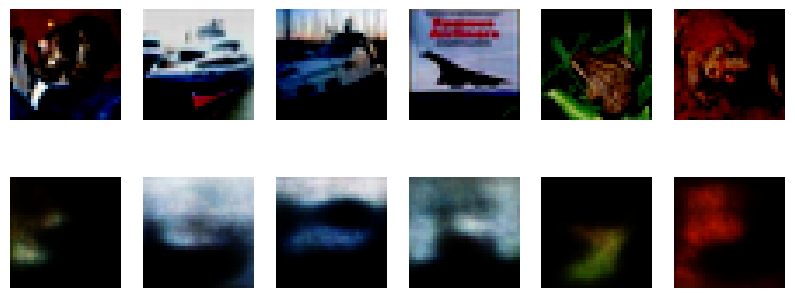

In [ ]:
# Get a batch of test images
dataiter = iter(testloader)
images, _ = next(dataiter)

# Flatten images
images_flat = images.view(images.size(0), -1).to(device)

# Pass through autoencoder
_, outputs = model(images_flat)

# Convert tensors to numpy arrays
images = images.numpy()
outputs = outputs.cpu().view(-1,3,32,32).detach().numpy()

# Number of images to display
n = 6

plt.figure(figsize=(10,4))

for i in range(n):

    # Display original image
    plt.subplot(2,n,i+1)
    plt.imshow(np.transpose(images[i], (1,2,0)))
    plt.axis("off")

    # Display reconstructed image
    plt.subplot(2,n,i+n+1)
    plt.imshow(np.transpose(outputs[i], (1,2,0)))
    plt.axis("off")

plt.show()

In [ ]:
sparsity_values = [1e-2, 1e-3, 1e-4]

for lambda_sparse in sparsity_values:

    print(f"\nTraining with sparsity value: {lambda_sparse}")

    model = SparseAutoencoder().to(device) # Move model to device
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Training
    for epoch in range(5):   # smaller epochs for quick experiment
        total_loss = 0

        for images, _ in trainloader:
            images = images.view(images.size(0), -1).to(device) # Move images to device

            optimizer.zero_grad()

            encoded, outputs = model(images) # Corrected assignment: encoded, outputs

            recon_loss = criterion(outputs, images)
            sparsity_loss = torch.mean(torch.abs(encoded))

            loss = recon_loss + lambda_sparse * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(trainloader)}")


Training with sparsity value: 0.01
Epoch 1, Loss: 0.21070832059816327
Epoch 2, Loss: 0.1880935898141178
Epoch 3, Loss: 0.1816913432553601
Epoch 4, Loss: 0.1796452178598365
Epoch 5, Loss: 0.17859531927596578

Training with sparsity value: 0.001
Epoch 1, Loss: 0.2048079581821666
Epoch 2, Loss: 0.1806049290520456
Epoch 3, Loss: 0.17442337303515285
Epoch 4, Loss: 0.17111328118445013
Epoch 5, Loss: 0.16926294226018365

Training with sparsity value: 0.0001
Epoch 1, Loss: 0.20933651577328782
Epoch 2, Loss: 0.18263560522090444
Epoch 3, Loss: 0.17458001594714193
Epoch 4, Loss: 0.17054192737087875
Epoch 5, Loss: 0.1678112685451727


In [ ]:
    # Testing
    test_loss = 0

    with torch.no_grad():
        for images, _ in testloader:
            images = images.view(images.size(0), -1).to(device)

            encoded, outputs = model(images)

            recon_loss = criterion(outputs, images)
            sparsity_loss = torch.mean(torch.abs(encoded))

            loss = recon_loss + lambda_sparse * sparsity_loss

            test_loss += loss.item()

    print(f"Test Loss for sparsity {lambda_sparse}: {test_loss/len(testloader)}")

Test Loss for sparsity 0.0001: 0.16483232473270804


Effect of Sparsity Regularization

λ = 1e-2 → Strong sparsity constraint, fewer neurons activated, reconstruction becomes slightly blurry.

λ = 1e-3 → Balanced sparsity and reconstruction quality.

λ = 1e-4 → Less sparsity, better reconstruction but weaker feature regularization.

Why blurred images : The autoencoder compresses the 3072-dimensional CIFAR-10 image into a small latent representation of 64 features. During compression some spatial information is lost, which results in blurred reconstructed images.

Sparse Autoencoder

A Sparse Autoencoder is a type of unsupervised neural network that learns compressed feature representations of input data while forcing most neurons to remain inactive.

Encoder

The encoder is the part of the autoencoder that compresses the input data into a lower-dimensional representation.

Example in your model:

3072 → 1024 → 256 → 64

Latent Representation

The latent representation is the compressed feature vector produced by the encoder.

In your model:

Latent dimension = 64

Reconstruction Loss

Reconstruction loss measures the difference between the original input image and the reconstructed output image.

In your code:

MSELoss

Formula concept:

Loss = (Original Image – Reconstructed Image)²

Sparsity Penalty

The sparsity penalty forces the model to activate only a few neurons in the hidden layer.

Prevent overfitting

Improve feature learning

Hyperparameters

Hyperparameters are settings chosen before training the model.

Examples from your lab:

Hyperparameter	Value
Batch size	128
Learning rate	0.001
Epochs	10
Sparsity weight (λ)	1e-3

Batch Size

Batch size is the number of training samples processed in one iteration.

Example:

Batch size = 128

Epoch

An epoch means one complete pass through the entire training dataset.

Example:

Epochs = 10

Flattening

Flattening converts an image into a 1-dimensional vector.

For CIFAR-10:

32 × 32 × 3 = 3072

Feature Representation

Feature representation means learning meaningful patterns from data instead of using raw input values.